# 07 — From-Scratch Text-to-Image Retrieval (ViT image + Transformer text)

## What this notebook is

A **dual-encoder retrieval model** trained entirely from random initialization on
Flickr30k. No pretrained weights, no `timm`, no `transformers` model classes —
only `torch.nn` primitives (`Conv2d`, `Linear`, `MultiheadAttention`,
`Embedding`, `LayerNorm`) plus `torch.optim.AdamW` and `torch.cuda.amp` for
mixed-precision training.

## Why it exists in this project

Notebooks 02–06 all build on a pretrained CLIP. That tells us how *adapting* a
foundation model behaves on Flickr30k. This notebook isolates **what is
learnable on Flickr30k alone**, i.e. the absolute floor of the comparison. The
gap between this and the CLIP-based approaches is the value of large-scale
contrastive pretraining (CLIP saw 400M image-text pairs; Flickr30k is 29K).

## Architecture in one breath

```
                                              ┌──────────────────┐
            image (3,224,224)  ─►  ViT-Small ─►│   image proj     │─► L2-norm 256-d
                                              └──────────────────┘
                                                      │
                                                  cosine sim   ←─── contrastive loss (InfoNCE)
                                                      │
                                              ┌──────────────────┐
            caption tokens (T,)  ─► Transformer ─►│    text proj     │─► L2-norm 256-d
                                              └──────────────────┘
```

| Component       | Spec                                                                |
| --------------- | ------------------------------------------------------------------- |
| Image encoder   | ViT, patch=16, dim=192, depth=6, heads=6, MLP ratio=4 → 192-d CLS  |
| Text encoder    | Transformer, dim=192, depth=4, heads=6, masked-mean pool → 192-d   |
| Joint head      | Two `Linear(192 → 256)` + L2 normalize                              |
| Loss            | `HardNegativeInfoNCELoss` (in-batch hard-negative weighted InfoNCE) |
| Total params    | ~5M (word vocab) / ~14M (BPE vocab)                                 |

## What we sweep

Two tokenizer variants run sequentially in the training loop:

1. **Word-level** vocab built from train captions (~17K tokens, `<pad><cls><unk><eos>` reserved). Every embedding starts random.
2. **CLIP BPE** vocab (49,408 BPE tokens). We reuse only the *tokenizer* — no pretrained embeddings are loaded; the embedding matrix is also random-initialized.

Both runs share everything else: same image encoder, same training schedule, same loss, same evaluation. The only thing that varies is the text-side input encoding.

## What you should see

| Signal         | Healthy run                                                                                       | Bad run                                                                                  |
| -------------- | ------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| `train/loss`   | Drops sharply for first ~500 steps, then a long slow descent; never NaN                          | Plateaus at log(B)≈4.85, or oscillates wildly, or NaN                                    |
| `train/acc_t2i`| Climbs from ~1/B (random) to >0.5 within a few hundred steps                                      | Stays at ~1/B forever                                                                    |
| `val/R@1`      | Climbs each epoch; reaches 0.05–0.20 by epoch 10–20 (much worse than CLIP — this is the point)    | Stuck at random (0.001 = 1/1000) → tokenizer or model wiring is broken                   |
| GPU util       | High (60–95% on 5090 with `num_workers≥4`)                                                        | Near 0% with high CPU → DataLoader bottleneck (raise `num_workers` or `BATCH_SIZE`)      |
| Gradient norm  | After clipping, around 1.0 (we clip at 1.0). Unclipped should rarely exceed 5–10                  | Repeatedly hitting 100+ pre-clip suggests instability                                    |

A useful sanity check: random retrieval baseline = K/N. For test split N=1000, that's R@1=0.001, R@5=0.005, R@10=0.01. Anything well above that means contrastive learning is actually happening.

Tracked end-to-end via Weights & Biases (project: `nsiete-flickr30k-clip`). Watch live there during training; per-epoch terminal lines flush only when the cell completes (nbconvert buffering).


## 1. Setup

The cell below does five things:

1. **Adds the project root to `sys.path`** so `from src.* import ...` works whether you launched Jupyter from `notebooks/` or from the project root.
2. **Imports torch + DataLoader** — the standard deep-learning stack.
3. **Imports our own modules**:
   - `src.config` for `set_seeds`, `WANDB_PROJECT`, paths, and `get_device()` (returns `cuda` on pectra, `mps` on Apple Silicon, else `cpu`).
   - `src.data` for the Karpathy-split-aware Flickr30k loader.
   - `src.evaluation` for `Recall@K` + `MedianR` + `MeanR` computation and the consolidated print/save helpers.
   - `src.training` for the contrastive losses (`HardNegativeInfoNCELoss`, `InfoNCELoss`), training-step machinery, validation runner, embedding encoders, and the wandb wrappers (`init_wandb` / `log_train_step` / `log_val_metrics` / `log_summary` / `log_artifact` / `finish_wandb`).
   - `src.scratch_model` for `build_vit_dual` (our encoder constructor) and `build_image_transform` (a torchvision pipeline using **ImageNet** stats — independent of CLIP).
   - `src.scratch_tokenizer` for `WordTokenizer` and `ClipBPETokenizer`.
   - `src.visualize` for matplotlib plotting helpers.
4. **Calls `set_seeds(42)`** — seeds Python's `random`, `numpy`, `torch` (CPU + CUDA + MPS), and sets `cudnn.deterministic=True`. Does NOT eliminate all sources of nondeterminism (multi-worker DataLoader shuffling for example), but two runs with the same seed should produce val curves that match within ~1%.
5. **Detects the device** and prints it. Anything other than `cuda` on pectra means something is wrong (driver mismatch, container quota, etc.).


In [1]:
import os
import sys
import gc
import time
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from src.config import (
    EMBEDDINGS_DIR,
    MODELS_DIR,
    RESULTS_DIR,
    WANDB_PROJECT,
    get_device,
    set_seeds,
)
from src.data import load_karpathy_splits, get_all_captions_flat
from src.evaluation import (
    evaluate_text_to_image,
    save_results,
    load_results,
    print_results_table,
)
from src.training import (
    ScratchRetrievalDataset,
    make_scratch_collate_fn,
    HardNegativeInfoNCELoss,
    get_optimizer,
    get_scheduler,
    training_step,
    run_validation_scratch,
    encode_images_scratch,
    encode_texts_scratch,
    init_wandb,
    log_train_step,
    log_val_metrics,
    log_summary,
    log_artifact,
    finish_wandb,
)
from src.scratch_model import (
    build_vit_dual,
    build_image_transform,
    count_params,
)
from src.scratch_tokenizer import WordTokenizer, ClipBPETokenizer
from src.visualize import plot_training_curves, plot_recall_comparison

set_seeds(42)
device = get_device()

# --- CUDA performance knobs (bypass strict determinism for ~10% speedup) ---
# These trade exact reproducibility for throughput. The seed call above still
# gives bit-identical *initialization*; only the kernel-selection / matmul
# precision is now non-deterministic.
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True            # autotune fastest conv kernels per shape
    torch.backends.cudnn.deterministic = False
    torch.backends.cuda.matmul.allow_tf32 = True     # use TF32 for fp32 matmul on Ampere+
    torch.backends.cudnn.allow_tf32 = True
    # Hint that input tensor shapes are fixed (BATCH_SIZE x 3 x 224 x 224)
    torch.set_float32_matmul_precision("high")

print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA capability: {torch.cuda.get_device_capability(0)}")
    print(f"  VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
  GPU: NVIDIA GeForce RTX 5090
  CUDA capability: (12, 0)
  VRAM total: 33.7 GB


## 2. Load data — what is "Karpathy split"?

Flickr30k ships with 31,783 images, each with 5 captions. Two split conventions exist:

- The **dataset's native split** — random.
- The **Karpathy split** (Karpathy & Fei-Fei, 2014) — used in *every* major retrieval paper since. 29,000 train / 1,014 val / 1,000 test, with the constraint that no image overlap exists between splits. We use this so our numbers are directly comparable to literature values.

`load_karpathy_splits()` reads the split assignments from `data/dataset_flickr30k.json` and joins them against the HuggingFace `lmms-lab/flickr30k` Arrow dataset. It returns `{"train": ds, "val": ds, "test": ds}` where each `ds` is a HuggingFace Dataset with columns `image` (PIL.Image), `caption` (list[str] of length 5), and a few metadata columns.

`get_all_captions_flat(splits["train"])` flattens the 5-captions-per-image structure into two arrays:

- `train_captions` — list of 145,000 caption strings (29,000 images × 5 captions)
- `train_gt`       — array of 145,000 image-indices, where `train_gt[i]` says which image caption `i` describes.

This is the format we need for retrieval training: each *caption* is an example, and we need to know which *image* is its ground truth.

For evaluation:
- Test split has 1,000 images × 5 captions = 5,000 captions.
- A query (caption) succeeds at R@1 if its ground-truth image is the top-1 retrieval among all 1,000 test images.
- Random baseline: R@1 = 1/1000 = 0.001.


In [2]:
splits = load_karpathy_splits()

train_captions, train_gt = get_all_captions_flat(splits["train"])
val_captions, val_gt = get_all_captions_flat(splits["val"])
test_captions, test_gt = get_all_captions_flat(splits["test"])

print(f"Train: {len(splits['train'])} images, {len(train_captions)} captions")
print(f"Val:   {len(splits['val'])} images, {len(val_captions)} captions")
print(f"Test:  {len(splits['test'])} images, {len(test_captions)} captions")


  train: 29000 images
  val: 1014 images
  test: 1000 images


Train: 29000 images, 145000 captions
Val:   1014 images, 5070 captions
Test:  1000 images, 5000 captions


## 3. Image preprocessing — why ImageNet stats and a custom pipeline

### Why not reuse `CLIPProcessor`?

Three reasons:

1. **Independence.** This experiment is the "from-scratch" arm. Reusing CLIP's preprocessing implicitly imports CLIP's color-statistics priors (mean=`(0.4815, 0.4578, 0.4082)`, std=`(0.2686, 0.2613, 0.2758)` derived from a curated subset of YFCC100M + LAION). Using the canonical ImageNet stats keeps us properly insulated.
2. **Story clarity.** "We trained a fresh ViT with ImageNet-style preprocessing" is a clean experimental description. "We used CLIP's preprocessor but trained the ViT from scratch" raises a small but irritating question: *how much of the result depends on CLIP's pixel mean/std?*
3. **Smaller dependency surface.** The path here is `torchvision.transforms` only — no `transformers` model class is imported.

### What the pipeline does

`build_image_transform(train=True)` returns a `Compose`:

```
Resize(256, BICUBIC) → RandomResizedCrop(224, scale=(0.85, 1.0)) → RandomHorizontalFlip → ToTensor → Normalize(IMAGENET_MEAN, IMAGENET_STD)
```

`build_image_transform(train=False)` is identical except the random crop is replaced by a deterministic `CenterCrop(224)` and there is no flip. Validation/test must be deterministic so metrics are reproducible.

`Normalize` subtracts mean and divides by std per channel. After this, pixel values are roughly in `[-2.1, 2.6]`, centered around 0.

### Why these augmentations?

- **Resize-then-crop** is standard for ImageNet-style models. We resize the short side to 256 then crop 224×224 because the random crop has more freedom this way.
- **Light random crop** (scale `0.85-1.0`) — keeps most of the image visible but adds positional jitter so the model doesn't memorize that captions describe centered objects.
- **Horizontal flip** — usually safe; captions like "A man on the *left*" do exist but they're a small minority. The slight disagreement is much smaller than the regularization gain.
- **No color jitter / auto-augment** — kept minimal so behavior matches the CLIP fine-tuning experiments and the comparison stays fair.


In [3]:
train_transform = build_image_transform(train=True)
eval_transform = build_image_transform(train=False)

# Sanity check shape on one image; should be (3, 224, 224) float32 with values
# roughly in [-2.1, 2.6] after ImageNet normalization.
sample_pixels = eval_transform(splits["test"][0]["image"].convert("RGB"))
print(f"image tensor shape: {tuple(sample_pixels.shape)}, dtype: {sample_pixels.dtype}, "
      f"min/max: {sample_pixels.min().item():.2f}/{sample_pixels.max().item():.2f}")


image tensor shape: (3, 224, 224), dtype: torch.float32, min/max: -2.12/2.64


## 4. Hyperparameters

### Dual sweep

`TOKENIZER_VARIANTS = ["word", "bpe"]` — the outer loop in the training cell will run training **twice**, once per tokenizer choice. Each run produces its own checkpoint, cached embeddings, results JSON, and wandb run.

### Schedule

- `NUM_EPOCHS = 30` is the production default. Override quickly via `EPOCH_OVERRIDE=2` env var for smoke tests.
- `BATCH_SIZE = 128` on CUDA, fallback `32` on MPS/CPU. The 5090 (32 GB) handles 128 with AMP comfortably for our small ViT-S model.
- `EVAL_BATCH_SIZE` is 2× `BATCH_SIZE` because validation is forward-only — no gradients, much smaller activation footprint.

### Optimization

- `LR = 5e-4` — random-init Transformers tolerate higher LR than fine-tuning. Standard ViT-from-scratch recipes go up to 1e-3; we stay slightly under for stability with a 6-block model.
- `WEIGHT_DECAY = 0.05` — common ViT regularization. Higher than CLIP fine-tuning (0.01) because random-init models are more prone to overfit a small dataset.
- `WARMUP_RATIO = 0.1` — first 10% of steps linearly ramp LR from 0 to `LR`, then cosine decay to 0. Warmup is critical for Transformers; without it, the first few steps with full LR can blow up the attention weights.
- `MAX_GRAD_NORM = 1.0` — global gradient norm clip. If the unclipped norm exceeds 1.0, we rescale all grads down. Prevents any single bad batch from destroying weights.
- `JOINT_DIM = 256` — the joint contrastive space is 256-d. Smaller than CLIP's 512 because we have less data and want a tighter manifold.


In [4]:
TOKENIZER_VARIANTS = ["word", "bpe"]
NUM_EPOCHS = int(os.environ.get("EPOCH_OVERRIDE", "30"))

# Larger batch -> more in-batch contrastive negatives -> stronger signal.
# 5090 has 32 GB; ViT-S + AMP comfortably handles BS=256. Override via env.
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "256" if device.type == "cuda" else "32"))
EVAL_BATCH_SIZE = int(os.environ.get("EVAL_BATCH_SIZE", "512" if device.type == "cuda" else "64"))

LR = 0.0005
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0
JOINT_DIM = 256
ARCH_TAG = "vit"

# DataLoader parallelism. Pectra has 48 cores -> 12 workers is a safe default
# that keeps the 5090 fed without saturating CPU. prefetch_factor=4 means each
# worker queues 4 batches ahead, so by the time the GPU finishes a step the
# next batch is already collated and pinned.
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", "12" if device.type == "cuda" else "0"))
PREFETCH_FACTOR = int(os.environ.get("PREFETCH_FACTOR", "4")) if NUM_WORKERS > 0 else None

# bfloat16 has the same dynamic range as fp32, so AMP is robust without a
# GradScaler. Blackwell (5090) has native bf16 tensor cores.
AMP_DTYPE = torch.bfloat16 if device.type == "cuda" else torch.float32
USE_AMP = device.type == "cuda"

print(
    f"NUM_EPOCHS={NUM_EPOCHS} BATCH_SIZE={BATCH_SIZE} LR={LR} "
    f"WEIGHT_DECAY={WEIGHT_DECAY} WARMUP_RATIO={WARMUP_RATIO}\n"
    f"NUM_WORKERS={NUM_WORKERS} PREFETCH_FACTOR={PREFETCH_FACTOR} "
    f"AMP={USE_AMP} ({AMP_DTYPE})"
)


NUM_EPOCHS=30 BATCH_SIZE=256 LR=0.0005 WEIGHT_DECAY=0.05 WARMUP_RATIO=0.1
NUM_WORKERS=12 PREFETCH_FACTOR=4 AMP=True (torch.bfloat16)


## 5. The training loop, demystified

This single cell is dense. Walking through what it does for each tokenizer variant:

### a. Build tokenizer

- **Word tokenizer**: `WordTokenizer.from_train_captions(train_captions)` makes one pass over all 145K train captions, counts words via `Counter`, keeps the top `max_vocab=20000` with `min_freq=3`, and reserves IDs 0–3 for `<pad><cls><unk><eos>`. The first time this runs it takes ~30–60s of CPU. Vocab size lands around 17K–18K. `unk_rate(val_captions)` reports the fraction of val tokens that map to `<unk>`; >5% means we should drop `min_freq`.
- **BPE tokenizer**: thin wrapper around the *tokenization* part of CLIP's tokenizer — no pretrained embedding weights are loaded. `vocab_size = 49408`. Per-caption sequence length is shorter on average than word-level because BPE merges common subwords.

### b. Build model

`build_vit_dual(vocab_size, max_length, pad_token_id, joint_dim)` returns a `DualEncoder` containing:

- `ImageEncoderViT`: patch embed (`Conv2d(3, 192, k=16, s=16)` → 14×14=196 patches) + learnable [CLS] token + learnable positional embedding (197, 192) + 6 `TransformerBlock`s with pre-norm + final LayerNorm. Returns the [CLS] row.
- `TextEncoderTransformer`: `Embedding(vocab, 192)` + learnable positional embed (max_length, 192) + 4 `TransformerBlock`s with `key_padding_mask` so padded positions are ignored by attention + masked-mean pool over non-pad tokens.
- Two `Linear(*.out_dim, 256)` heads + L2 normalize at the joint output.

`count_params(model)` reports trainable params: ~4.7M (word) / ~14.2M (BPE). Most of the BPE difference is the embedding matrix (49,408 × 192 ≈ 9.5M).

### c. Data pipeline

`ScratchRetrievalDataset` yields one `(image_tensor, caption_str)` per item. The collate function tokenizes captions in batch and stacks pixel tensors. Important DataLoader knobs:

- `num_workers = NUM_WORKERS_DEFAULT` — multiprocess data loading. Critical for CUDA: PIL decode + transforms happen on CPU, and a single worker bottlenecks the GPU. With 4 workers the pipeline keeps the 5090 fed.
- `pin_memory = True` on CUDA — allocates tensors in pinned (page-locked) host memory so `.to(device, non_blocking=True)` can overlap CPU→GPU transfers with compute.
- `persistent_workers = True` — workers are kept alive across epochs instead of being recreated each epoch. Saves the cold-start cost (~0.5s/worker).
- `drop_last = True` — drops the last partial batch so all batches have exactly `BATCH_SIZE` samples; in-batch contrastive loss is sensitive to batch size variation.

### d. Loss / optimizer / scheduler / AMP

- `HardNegativeInfoNCELoss(temperature=0.07)` — see the deep-dive below.
- `AdamW` with `lr` and `weight_decay` from hyperparams. AdamW decouples weight decay from the gradient update (vs Adam's L2 regularization) — empirically much better for Transformers.
- Linear warmup + cosine decay scheduler.
- **bfloat16 mixed-precision** on CUDA via `torch.amp.autocast(dtype=torch.bfloat16)`. bf16 has the same exponent range as fp32 (8 bits) but only 7 mantissa bits, so dynamic range is preserved while throughput on Blackwell tensor cores roughly doubles vs fp32. **No `GradScaler` is needed** — the gradient scaling dance is only there to keep fp16 magnitudes inside its narrow exponent range; bf16 sidesteps the problem entirely. This is more stable than fp16 and the training loop becomes a clean 4 lines.

### e. WandB initialization

`init_wandb(...)` opens a run with full hyperparameter config and tags. `wandb.watch(model, log="gradients", log_freq=200)` registers hooks so per-parameter gradient histograms are logged every 200 steps — useful for spotting layer-specific divergence.

### f. Inner training loop

```
for epoch in range(NUM_EPOCHS):
    for batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        with autocast(dtype=bf16):
            loss, metrics = training_step(model, batch, loss_fn, device)
        loss.backward()                                    # plain backward — bf16 keeps fp32 range
        clip_grad_norm_(model.parameters(), MAX_GRAD_NORM) # global gradient norm clip
        optimizer.step()
        scheduler.step()
        log_train_step({...}, step=global_step)
    # then validation + best-checkpoint save
```

Why this loop is fast on the 5090:

1. **`autocast` context**: forward + backward runs in bf16 on supported ops (matmul, conv, attention). LayerNorm and softmax auto-stay in fp32 because they need the precision.
2. **No GradScaler**: bf16 gradients are already in normal-magnitude land, so we go straight to `loss.backward()`.
3. **`clip_grad_norm_`** caps the global gradient norm at 1.0. Mandatory for transformer training without warmup-only LR.
4. **`optimizer.step()`** + **`scheduler.step()`** advance both AdamW and the LR cosine schedule.

CPU-side, the DataLoader workers are doing JPEG decode + transforms + tokenization in parallel, so by the time the GPU finishes step N the next batch is already pinned and waiting.

### g. HardNegativeInfoNCELoss — what it does

Standard InfoNCE uses the cosine similarity matrix `S = (image @ text.T) / temperature` (shape `B×B`) and treats the diagonal as positives, off-diagonals as in-batch negatives. Cross-entropy in both directions, averaged.

Hard-negative variant *additionally weights the hardest negatives* — the off-diagonal entries with highest cosine similarity (where the model is "most confused") contribute proportionally more to the loss. This pushes the encoder to fix its worst mistakes rather than its average mistakes.

`temperature=0.07` is the standard value (CLIP, SimCLR all use this). Lower values make the loss sharper; too low and gradients explode early in training.

### h. Per-epoch validation

`run_validation_scratch(model, tokenizer, eval_transform, val_split, val_captions, val_gt, device, batch_size)`:

1. Sets `model.eval()` and saves the previous mode for restore.
2. Encodes all 1,014 val images with `eval_transform` (no augmentation).
3. Tokenizes + encodes all 5,070 val captions with the chosen tokenizer.
4. Computes the 5070×1014 similarity matrix and ranks the ground truth image for each caption.
5. Returns `{R@1, R@5, R@10, MedianR, MeanR}`.

This is the same metric calculation as for CLIP — fair comparison.

### i. Best-checkpoint saving

If `val/R@1` improved over the running best, save the model state_dict, current epoch, val metrics, and avg train loss to `data/models/scratch_vit_<tok>/best.pt`. Tokenizer is also saved to the same dir so the app can rehydrate later.

### j. Test-set evaluation (after the inner loop)

Reload the best checkpoint (not the last-epoch state — best may have been epoch 25 of 30). Encode the test split, cache embeddings under `data/embeddings/scratch_vit_<tok>_{images,texts}_test.npy` (so the comparison cell in NB 06 picks them up automatically), evaluate, save JSON. Push test summary + checkpoint artifact to wandb.

### k. Cleanup between variants

`del model, optimizer, scheduler, train_loader, train_dataset` then `gc.collect()` + `torch.cuda.empty_cache()`. Without this, activation buffers + model weights from the first variant linger and shrink the headroom available for the BPE variant (which is larger because of the bigger embedding matrix).


In [5]:
RUN_TRAINING = True

results_per_variant: dict[str, dict] = {}
history_per_variant: dict[str, dict] = {}

if RUN_TRAINING:
    for tok_name in TOKENIZER_VARIANTS:
        run_name = f"scratch_{ARCH_TAG}_{tok_name}"
        print(f"\n{'='*70}\n>>> Variant: {run_name}\n{'='*70}")

        # --- (a) Tokenizer ---
        if tok_name == "word":
            tokenizer = WordTokenizer.from_train_captions(train_captions, max_length=32)
            print(f"WordTokenizer vocab_size={tokenizer.vocab_size}, "
                  f"unk_rate(val)={tokenizer.unk_rate(val_captions):.4f}")
        else:
            tokenizer = ClipBPETokenizer(max_length=32)
            print(f"ClipBPETokenizer vocab_size={tokenizer.vocab_size}")

        # --- (b) Model ---
        model = build_vit_dual(
            vocab_size=tokenizer.vocab_size,
            max_length=tokenizer.max_length,
            pad_token_id=tokenizer.pad_token_id,
            joint_dim=JOINT_DIM,
        ).to(device)
        n_params = count_params(model)
        print(f"Model parameters: {n_params:,}")

        # --- (c) Data pipeline ---
        train_dataset = ScratchRetrievalDataset(splits["train"], image_transform=train_transform)
        loader_kwargs = dict(
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=make_scratch_collate_fn(tokenizer),
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == "cuda"),
            persistent_workers=(NUM_WORKERS > 0),
            drop_last=True,
        )
        if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
            loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
        train_loader = DataLoader(train_dataset, **loader_kwargs)
        steps_per_epoch = len(train_loader)
        total_steps = steps_per_epoch * NUM_EPOCHS
        print(f"Batches/epoch: {steps_per_epoch}, total steps: {total_steps}")

        # --- (d) Loss / optimizer / scheduler ---
        # No GradScaler: bf16 has fp32-equivalent dynamic range.
        loss_fn = HardNegativeInfoNCELoss(temperature=0.07)
        optimizer = get_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = get_scheduler(optimizer, total_steps, warmup_ratio=WARMUP_RATIO)

        # --- (e) Save dir + tokenizer ---
        save_dir = MODELS_DIR / run_name
        save_dir.mkdir(parents=True, exist_ok=True)
        tokenizer.save(save_dir)  # so the app can rehydrate later

        # --- (f) WandB ---
        run = init_wandb(
            run_name=run_name,
            config={
                "approach": "scratch",
                "architecture": ARCH_TAG,
                "tokenizer": tok_name,
                "vocab_size": tokenizer.vocab_size,
                "max_text_length": tokenizer.max_length,
                "joint_dim": JOINT_DIM,
                "trainable_params": n_params,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "num_epochs": NUM_EPOCHS,
                "weight_decay": WEIGHT_DECAY,
                "warmup_ratio": WARMUP_RATIO,
                "max_grad_norm": MAX_GRAD_NORM,
                "temperature": 0.07,
                "hard_negative_weight": 2.0,
                "loss": "HardNegativeInfoNCE",
                "amp": device.type == "cuda",
                "num_workers": NUM_WORKERS,
                "seed": 42,
                "device": str(device),
            },
            tags=["scratch", ARCH_TAG, tok_name],
        )
        try:
            import wandb
            wandb.watch(model, log="gradients", log_freq=200)
        except Exception:
            pass

        # --- (g) Inner training loop ---
        best_val_r1 = 0.0
        train_losses: list[float] = []
        val_metrics_history: dict[str, list[float]] = {"R@1": [], "R@5": [], "R@10": []}
        global_step = 0

        for epoch in range(NUM_EPOCHS):
            model.train()
            epoch_losses: list[float] = []
            ep_start = time.time()
            for batch in train_loader:
                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast(
                    device_type=device.type, enabled=USE_AMP, dtype=AMP_DTYPE
                ):
                    loss, metrics = training_step(model, batch, loss_fn, device)

                # bf16 keeps fp32 range, so plain backward + clip + step works
                # without a GradScaler.
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()

                epoch_losses.append(metrics["loss"])
                train_losses.append(metrics["loss"])
                global_step += 1

                log_train_step(
                    {
                        "loss": metrics["loss"],
                        "acc_i2t": metrics["acc_i2t"],
                        "acc_t2i": metrics["acc_t2i"],
                        "lr": scheduler.get_last_lr()[0],
                    },
                    step=global_step,
                )

            avg_loss = float(np.mean(epoch_losses))

            # --- (h) Per-epoch validation ---
            val = run_validation_scratch(
                model,
                tokenizer,
                eval_transform,
                splits["val"],
                val_captions,
                val_gt,
                device=device,
                batch_size=EVAL_BATCH_SIZE,
            )
            for k in ["R@1", "R@5", "R@10"]:
                val_metrics_history[k].append(val[k])

            log_val_metrics({**val, "epoch_loss": avg_loss}, epoch=epoch)
            print(
                f"[{tok_name}] Epoch {epoch+1} done in {time.time() - ep_start:.0f}s: "
                f"loss={avg_loss:.4f} | "
                f"Val R@1={val['R@1']:.3f} R@5={val['R@5']:.3f} R@10={val['R@10']:.3f}",
                flush=True,
            )

            # --- (i) Best-checkpoint save ---
            if val["R@1"] > best_val_r1:
                best_val_r1 = val["R@1"]
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "epoch": epoch,
                        "val_results": val,
                        "loss": avg_loss,
                    },
                    save_dir / "best.pt",
                )
                print(f"[{tok_name}]   -> New best (R@1={best_val_r1:.3f}); checkpoint saved", flush=True)

        print(f"[{tok_name}] Best val R@1: {best_val_r1:.3f}", flush=True)

        # --- (j) Test-set evaluation (reload best) ---
        ckpt = torch.load(save_dir / "best.pt", map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        test_img_emb = encode_images_scratch(
            splits["test"], model, eval_transform, device=device, batch_size=EVAL_BATCH_SIZE
        )
        test_txt_emb = encode_texts_scratch(
            test_captions, model, tokenizer, device=device, batch_size=EVAL_BATCH_SIZE * 2
        )

        np.save(EMBEDDINGS_DIR / f"{run_name}_images_test.npy", test_img_emb)
        np.save(EMBEDDINGS_DIR / f"{run_name}_texts_test.npy", test_txt_emb)
        print(f"[{tok_name}] Cached test embeddings: imgs={test_img_emb.shape} txts={test_txt_emb.shape}")

        test_results = evaluate_text_to_image(test_txt_emb, test_img_emb, test_gt)
        save_results(test_results, run_name)
        print(f"[{tok_name}] Test results:")
        for k, v in test_results.items():
            print(f"  {k}: {v:.1%}" if k.startswith("R@") else f"  {k}: {v:.4f}")

        log_summary(test_results, prefix="test")
        log_artifact(save_dir / "best.pt", name=run_name, artifact_type="model")
        finish_wandb()

        results_per_variant[run_name] = test_results
        history_per_variant[run_name] = {
            "train_losses": train_losses,
            "val_metrics_history": val_metrics_history,
        }

        # --- (k) Cleanup between variants ---
        del model, optimizer, scheduler, train_loader, train_dataset
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\nAll variants done.")



>>> Variant: scratch_vit_word


WordTokenizer vocab_size=9471, unk_rate(val)=0.0089
Model parameters: 6,558,464
Batches/epoch: 113, total steps: 3390


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/students/xvysnya/.netrc.


wandb: Currently logged in as: vysnyandrej (vysnyandrej-slovak-university-of-technology-in-bratislava) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


...

wandb: 
wandb: Run history:
wandb: train/acc_i2t ▁▁▁▁▂▃▂▂▂▃▃▂▃▃▃▃▄▄▄▄▄▄▅▄▅▆▅▆▇▆▆██▆▇██▇▇▇
wandb: train/acc_t2i ▁▂▂▂▂▂▃▄▃▃▄▄▃▃▃▄▅▅▅▅▄▆▅▇▅▆▆▅▇▇▆▇▇▇▆██▆▇▇
wandb:    train/loss ██▇▇▆▆▅▆▅▅▅▄▅▅▅▅▄▄▄▃▃▄▃▃▃▃▂▂▃▂▂▂▂▂▁▂▁▂▂▁
wandb:      train/lr ▁▂▃▃▄▅██████▇▇▇▇▆▆▅▅▅▄▄▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:    test/MeanR 142.392
wandb:  test/MedianR 59
wandb:      test/R@1 0.0406
wandb:     test/R@10 0.2042
wandb:      test/R@5 0.125
wandb: train/acc_i2t 0.20312
wandb: train/acc_t2i 0.19141
wandb:    train/loss 3.36677
wandb:      train/lr 0
wandb: 


wandb: 🚀 View run scratch_vit_bpe at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip/runs/zrchacgi
wandb: ⭐️ View project at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip
wandb: Synced 5 W&B file(s), 0 media file(s), 2 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260504_231600-zrchacgi/logs


wandb: WARNING Tried to log to step 29 that is less than the current step 3390. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.



All variants done.


## 6. How to validate this run is healthy

Use these signals together — any one in isolation can mislead.

### From terminal output (when each cell finishes)

| Look for                                                            | Meaning                                                                    |
| ------------------------------------------------------------------- | -------------------------------------------------------------------------- |
| `WordTokenizer vocab_size=17xxx, unk_rate(val)=0.0xxx`              | Tokenizer is built. UNK rate <2% is fine; >5% drop `min_freq`.            |
| `Model parameters: 4,7xx,xxx` (word) or `14,2xx,xxx` (BPE)          | Model wired correctly.                                                     |
| `Epoch 1 done in Xs: loss=...` per epoch                            | Single line per epoch. Loss should drop monotonically (small noise OK).   |
| `New best (R@1=...)` lines every few epochs                         | Validation is improving.                                                   |

### From WandB (live)

| Panel                              | Healthy                                              | Investigate if                                              |
| ---------------------------------- | ---------------------------------------------------- | ----------------------------------------------------------- |
| `train/loss`                       | Drops steeply for 200-500 steps, then long plateau   | Stays at log(B)≈4.85, never moves                           |
| `train/acc_t2i`, `train/acc_i2t`   | Climb together from ~1/B to >0.5                     | Diverge sharply — sometimes one direction over-trains       |
| `train/lr`                         | Linear ramp in first 10%, then cosine                | Flat → scheduler not stepping                               |
| `val/R@1`                          | Climbs steadily, plateaus around epoch 20–25         | Drops after a few epochs → overfitting                      |
| `val/R@5`, `val/R@10`              | Roughly track R@1                                    | All zero → eval pipeline mismatch (tokenizer / shape)       |
| Gradient histograms (`gradients/`) | Centered, not too narrow, no exploding tails         | Repeated huge spikes in attention layers → reduce LR        |
| GPU util (system metrics)          | 60-95% on RTX 5090 with 4 workers                    | <20% → DataLoader bottleneck, raise `num_workers`           |
| GPU memory                         | ~6-15 GB                                             | Climbing without bound → memory leak (rare in our setup)    |

### From the test summary (final)

After both variants finish, the comparison cell will load all available result JSONs and print a table. For from-scratch ViT on Flickr30k with 30 epochs, expect:

- `R@1` ≈ 0.05–0.20 (5–20% — much worse than CLIP zero-shot's 0.586, this is the expected gap)
- `R@5` ≈ 0.15–0.40
- `R@10` ≈ 0.25–0.50
- `MedianR` ≈ 30–150 (random would be 500)
- BPE variant typically beats word-level by 1–3 R@1 percentage points

If R@1 < 0.005 (5× random), something is wrong: check that ground-truth indices align between train/val/test, and that the tokenizer is the same for training and validation (the cell uses `tokenizer` for both — should be impossible to mix up, but worth a sanity check).

### Common failure modes & fixes

| Symptom                                              | Likely cause                                | Fix                                                       |
| ---------------------------------------------------- | ------------------------------------------- | --------------------------------------------------------- |
| Loss → NaN early                                     | LR too high, no warmup, fp16 overflow       | Drop LR to 1e-4, increase warmup                          |
| Val R@1 stuck at 0.001                               | tokenizer mismatch, label shuffle           | Check that `val_gt` aligns with caption order             |
| Train loss drops, val R@1 doesn't                    | Train/val data leakage in your pipeline OR  | Verify `splits["train"]` and `splits["val"]` are disjoint |
|                                                      | augmentation is too aggressive              | (Flickr30k Karpathy split guarantees disjoint already)    |
| Val R@1 climbs then drops (overfit)                  | Model too big / regularization too low      | Raise dropout, weight decay, or use early stopping        |
| Both tokenizer variants give nearly identical R@1    | Likely fine — BPE advantage is small at 29K | Compare R@5 / val curves for finer-grained evidence       |


## 7. Cross-approach comparison

We load every results JSON we can find from earlier notebooks and render a table + bar chart. Missing results (e.g., Full FT not yet trained) are simply skipped. This cell is also re-runnable later, after notebooks 02–06 + 08 have populated the rest.

What to look for in the bar chart:
- The **gap** between any CLIP-derived row and the from-scratch rows. That gap quantifies how much pretraining buys you.
- The **gap** between the two tokenizer variants. Usually small (1–3 R@1 percentage points) but consistent.
- Whether bigger models (BPE has more embedding params) translate to better R@1 — sometimes yes, sometimes the dataset is too small to absorb the extra capacity.



  Scratch ViT vs CLIP variants
Model                           R@1       R@5      R@10   MedianR     MeanR
---------------------------------------------------------------------------
scratch_vit_word              3.4%    12.9%    19.9%      61.0     141.1
scratch_vit_bpe               4.1%    12.5%    20.4%      59.0     142.4
CLIP B/32 (baseline)         58.6%    83.5%    89.9%       1.0       6.1
CLIP B/16 (baseline)         62.1%    85.6%    92.0%       1.0       5.0
CLIP B/32 + Projection       63.7%    88.2%    93.5%       1.0       4.7
CLIP B/32 Full FT            68.5%    90.1%    94.3%       1.0       3.8
CLIP B/32 + LoRA (r=8)       67.3%    89.4%    94.2%       1.0       4.0



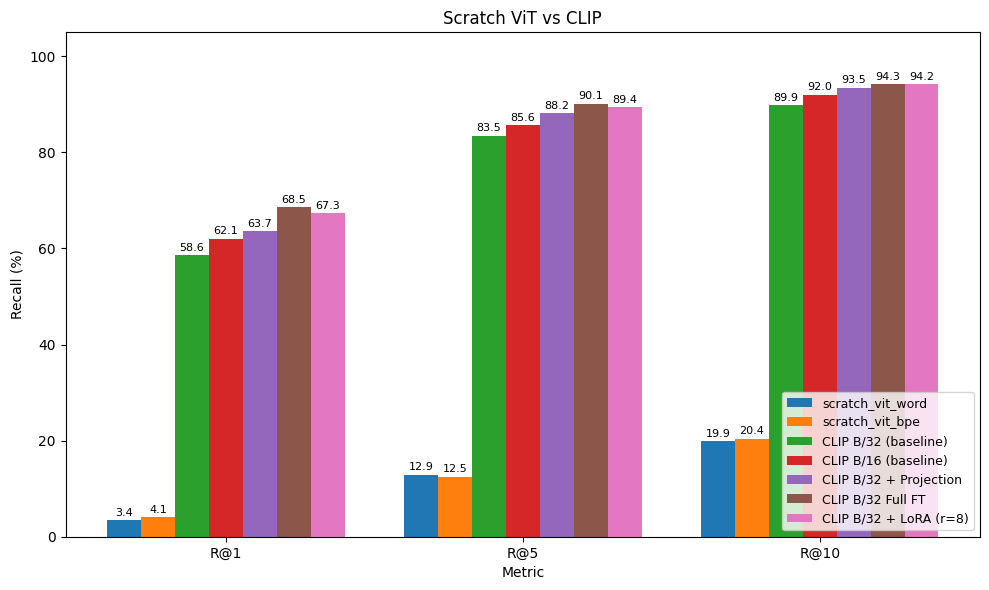

In [6]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    comparison: dict[str, dict] = dict(results_per_variant)

    for display, candidates in [
        ("CLIP B/32 (baseline)", ["baseline_b32", "baseline_clip-vit-b-32"]),
        ("CLIP B/16 (baseline)", ["baseline_b16", "baseline_clip-vit-b-16"]),
        ("CLIP B/32 + Projection", ["projection_head_b32"]),
        ("CLIP B/32 Full FT", ["full_finetune_b32"]),
        ("CLIP B/32 + LoRA (r=8)", ["lora_b32"]),
    ]:
        for fname in candidates:
            try:
                comparison[display] = load_results(fname)
                break
            except FileNotFoundError:
                continue

    print_results_table(comparison, title="Scratch ViT vs CLIP variants")
    plot_recall_comparison(comparison, title="Scratch ViT vs CLIP")


## 8. Training curves

`plot_training_curves` renders two side-by-side matplotlib panels per variant:

- **Left**: per-step training loss. Should drop quickly then taper.
- **Right**: per-epoch `val/R@K` for K=1,5,10. R@1 climbs slowest, R@10 fastest.

Compare both variants visually to see whether one converges faster, plateaus higher, or has a noisier loss curve.

WandB has the same curves (and many more like gradient histograms, system metrics). Use WandB during training, these matplotlib plots after, when you want a single self-contained PDF/PNG-friendly output.


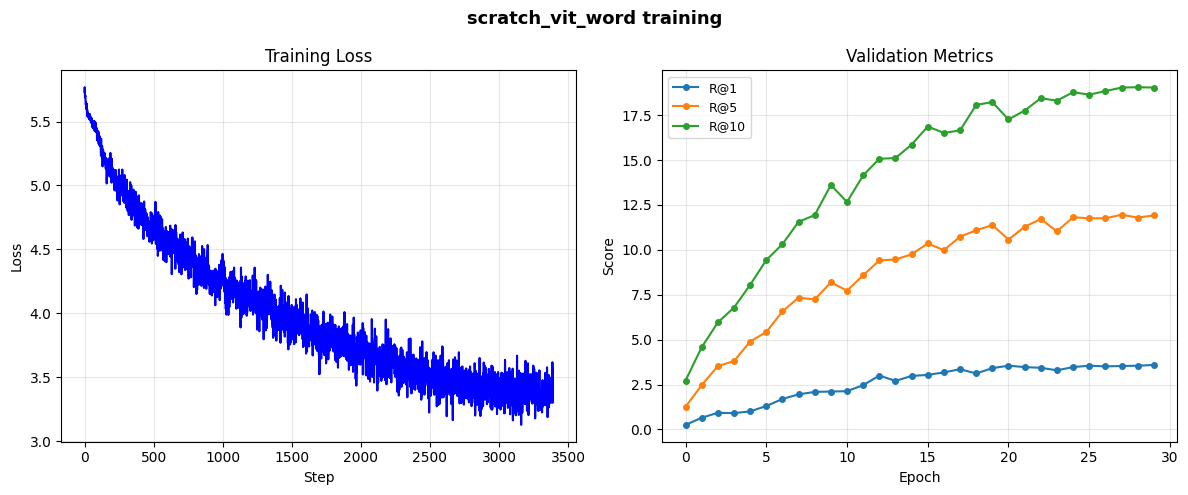

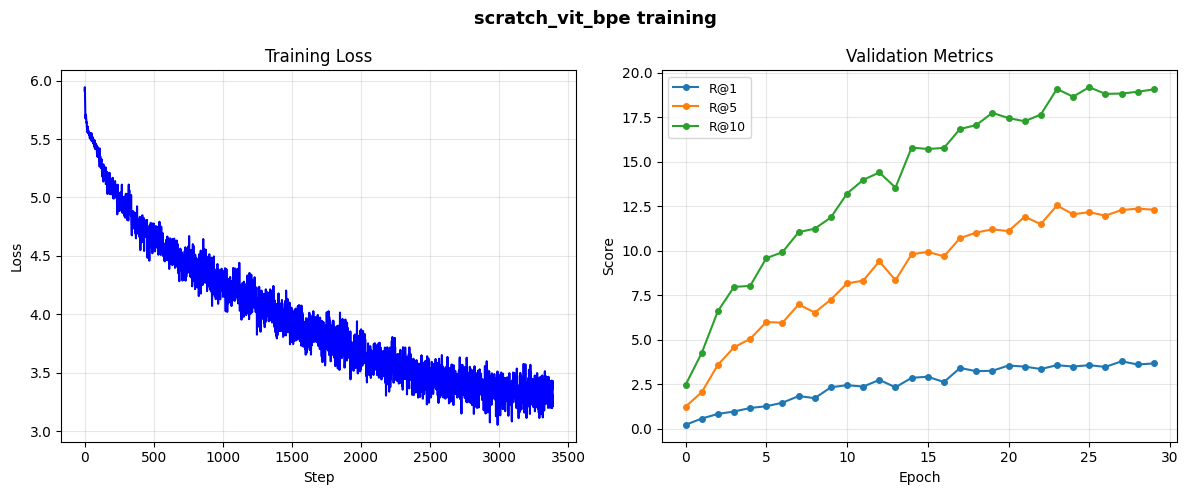

In [7]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    for run_name, hist in history_per_variant.items():
        plot_training_curves(
            hist["train_losses"], hist["val_metrics_history"], title=f"{run_name} training"
        )
